# Data Exploration


In [160]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats
from src.common import mpl_apply
import matplotlib.dates as mdates

In [161]:
df = pd.read_csv("../data/climate-daily_complete.csv")
df.head()

,x,y,STATION_NAME,CLIMATE_IDENTIFIER,ID,LOCAL_DATE,LOCAL_DATE_dt,PROVINCE_CODE,LOCAL_YEAR,LOCAL_MONTH,LOCAL_DAY,MEAN_TEMPERATURE,MIN_TEMPERATURE,MAX_TEMPERATURE,TOTAL_PRECIPITATION,TOTAL_RAIN,TOTAL_SNOW,SNOW_ON_GROUND,COOLING_DEGREE_DAYS,HEATING_DEGREE_DAYS
0,-52.742778,47.622222,ST JOHN'S A,8403506,8403506.2000.1.1,2000-01-01 00:00:00,2000-01-01,NL,2000,1,1,-8.3,-12.3,-4.2,0.2,0.0,0.2,6.0,0.0,26.3
1,-52.742778,47.622222,ST JOHN'S A,8403506,8403506.2000.1.2,2000-01-02 00:00:00,2000-01-02,NL,2000,1,2,-3.9,-8.8,1.1,0.4,0.0,0.4,6.0,0.0,21.9
2,-52.742778,47.622222,ST JOHN'S A,8403506,8403506.2000.1.3,2000-01-03 00:00:00,2000-01-03,NL,2000,1,3,-1.1,-7.5,5.3,11.9,4.3,7.6,6.0,0.0,19.1
3,-52.742778,47.622222,ST JOHN'S A,8403506,8403506.2000.1.4,2000-01-04 00:00:00,2000-01-04,NL,2000,1,4,-4.6,-9.7,0.6,1.1,1.1,0.0,3.0,0.0,22.6
4,-52.742778,47.622222,ST JOHN'S A,8403506,8403506.2000.1.5,2000-01-05 00:00:00,2000-01-05,NL,2000,1,5,7.2,-0.6,15.0,12.5,12.3,0.2,0.0,0.0,10.8


In [162]:
df = df.sort_values('LOCAL_DATE')

In [163]:
df.STATION_NAME.unique()

array(["ST JOHN'S A", 'ST JOHNS WEST CLIMATE'], dtype=object)

In [164]:
mpl_apply()

In [165]:
# Create datetime from year/month/day
df['date'] = pd.to_datetime(df[['LOCAL_YEAR', 'LOCAL_MONTH', 'LOCAL_DAY']].rename(columns={
    'LOCAL_YEAR': 'year',
    'LOCAL_MONTH': 'month',
    'LOCAL_DAY': 'day'
}))

# Sort by date
df = df.sort_values('date')

In [166]:
df.columns

Index(['x', 'y', 'STATION_NAME', 'CLIMATE_IDENTIFIER', 'ID', 'LOCAL_DATE',
       'LOCAL_DATE_dt', 'PROVINCE_CODE', 'LOCAL_YEAR', 'LOCAL_MONTH',
       'LOCAL_DAY', 'MEAN_TEMPERATURE', 'MIN_TEMPERATURE', 'MAX_TEMPERATURE',
       'TOTAL_PRECIPITATION', 'TOTAL_RAIN', 'TOTAL_SNOW', 'SNOW_ON_GROUND',
       'COOLING_DEGREE_DAYS', 'HEATING_DEGREE_DAYS', 'date'],
      dtype='object')

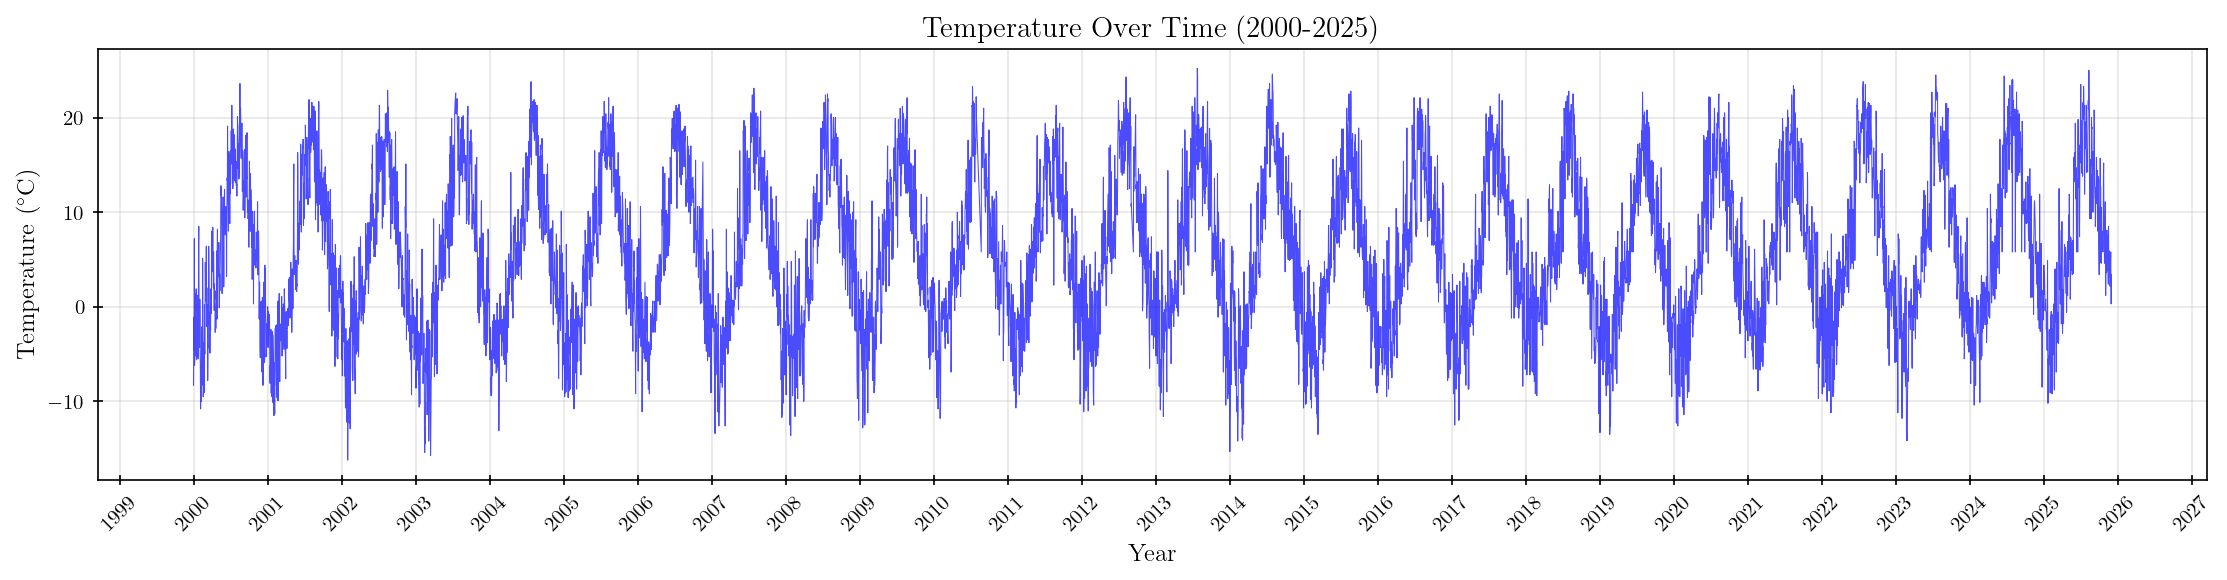

In [ ]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df['date'], df['MEAN_TEMPERATURE'],
        linewidth=0.5, alpha=0.7, color='blue')

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature ($^{\\circ}$C)', fontsize=12)
ax.set_title('Temperature Over Time (2000-2025)', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()

## DTR Analysis

In [168]:
# Import DTR function
from src.dtr_calc import calculate_dtr

In [169]:
# Calculate dtr time series data
df["DTR"] = calculate_dtr(t_min=df["MIN_TEMPERATURE"],
                          t_max=df["MAX_TEMPERATURE"])

ValueError: t_min must be <= t_max for all entries

In [170]:
df.columns

Index(['x', 'y', 'STATION_NAME', 'CLIMATE_IDENTIFIER', 'ID', 'LOCAL_DATE',
       'LOCAL_DATE_dt', 'PROVINCE_CODE', 'LOCAL_YEAR', 'LOCAL_MONTH',
       'LOCAL_DAY', 'MEAN_TEMPERATURE', 'MIN_TEMPERATURE', 'MAX_TEMPERATURE',
       'TOTAL_PRECIPITATION', 'TOTAL_RAIN', 'TOTAL_SNOW', 'SNOW_ON_GROUND',
       'COOLING_DEGREE_DAYS', 'HEATING_DEGREE_DAYS', 'date'],
      dtype='object')

In [171]:
# Find invalid rows
invalid = df[df["MAX_TEMPERATURE"] < df["MIN_TEMPERATURE"]]
print(invalid[["date", "MIN_TEMPERATURE", "MAX_TEMPERATURE", "STATION_NAME"]])

           date  MIN_TEMPERATURE  MAX_TEMPERATURE           STATION_NAME
8397 2023-01-31             2.06              1.6  ST JOHNS WEST CLIMATE
9048 2024-11-12             2.06              1.6  ST JOHNS WEST CLIMATE


In [172]:
print(f"Invalid samples: {len(invalid)}")
print(f"Total number of samples: {df.shape[0]}")

Invalid samples: 2
Total number of samples: 9433


In [173]:
# Drop invalid rows and create clean copy
df = df[df["MAX_TEMPERATURE"] >= df["MIN_TEMPERATURE"]].copy()
print(f"Samples left: {len(df)}")

Samples left: 9431


In [174]:
# Calculate DTR (no warning)
df["DTR"] = calculate_dtr(t_min=df["MIN_TEMPERATURE"],
                          t_max=df["MAX_TEMPERATURE"])

#### All DTR samples

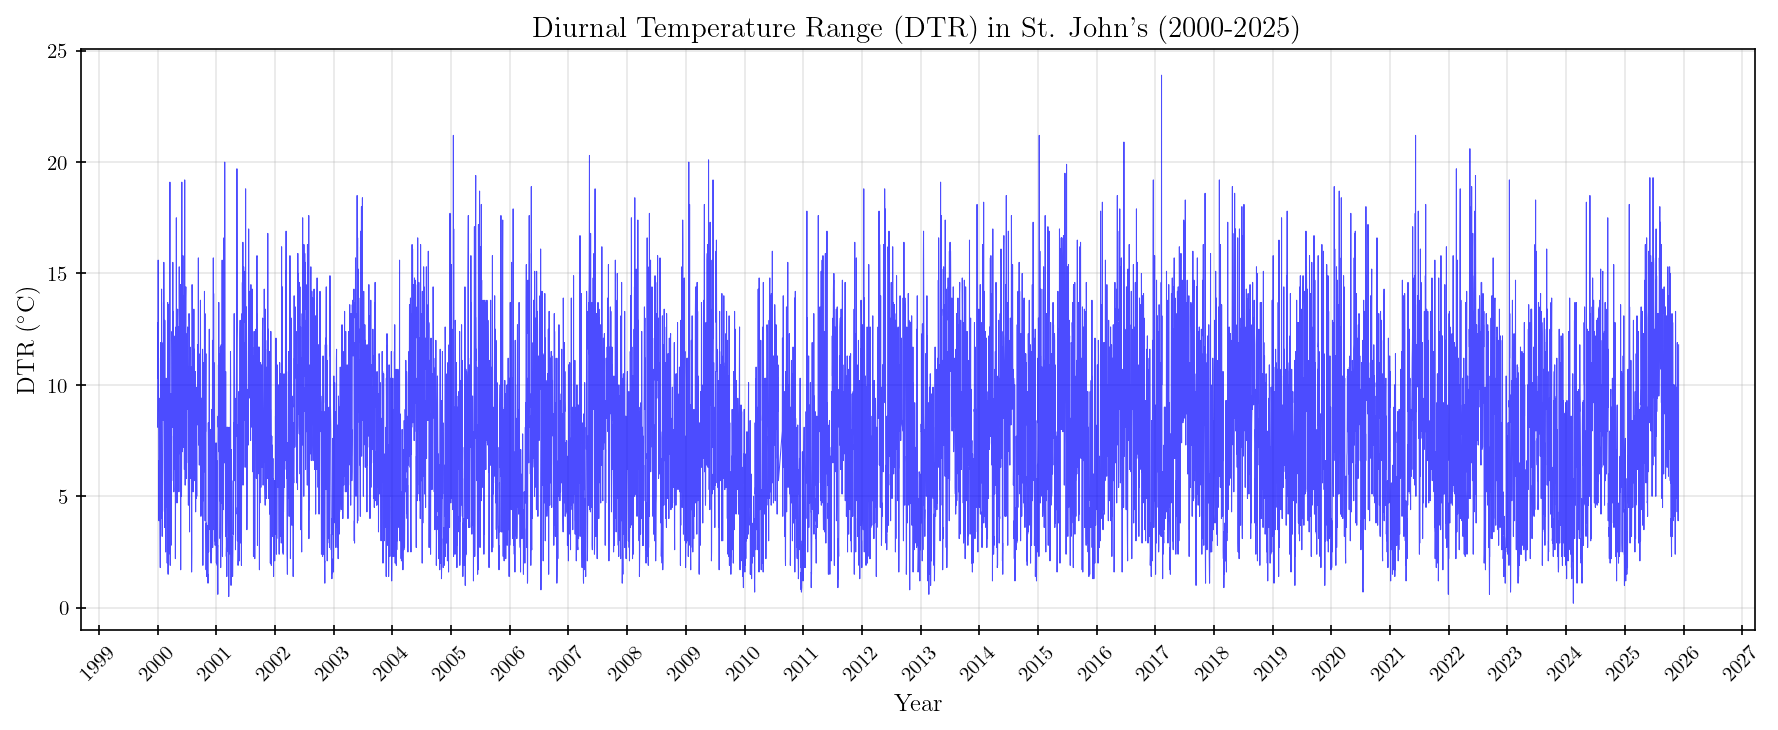

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["DTR"], color="blue", linewidth=0.5, alpha=0.7)
plt.title('Diurnal Temperature Range (DTR) in St. John\'s (2000-2025)')
plt.xlabel('Year')
plt.ylabel('DTR ($^{\\circ}$C)')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plotting individual DTR values for each day, provides visual noise. I will try to see if I can find any trends/patterns in the yearly and/or monthly plot.

#### Yearly Mean DTR

In [176]:
# Calculate annual mean DTR
annual_dtr = df.groupby(df['date'].dt.year)['DTR'].mean()

# Fit linear trend
slope, intercept, r_value, p_value, std_err = stats.linregress(
    annual_dtr.index, annual_dtr.values
)

# Print statistics
print(f"Slope: {slope:.4f} °C/year")
print(f"Intercept: {intercept:.2f} °C")
print(f"p-value: {p_value:.3f}")
print(f"R²: {r_value**2:.3f}")
print(f"Significant at alpha=0.05? {'Yes' if p_value < 0.05 else 'No'}")

Slope: 0.0097 °C/year
Intercept: -11.57 °C
p-value: 0.466
R²: 0.022
Significant at alpha=0.05? No


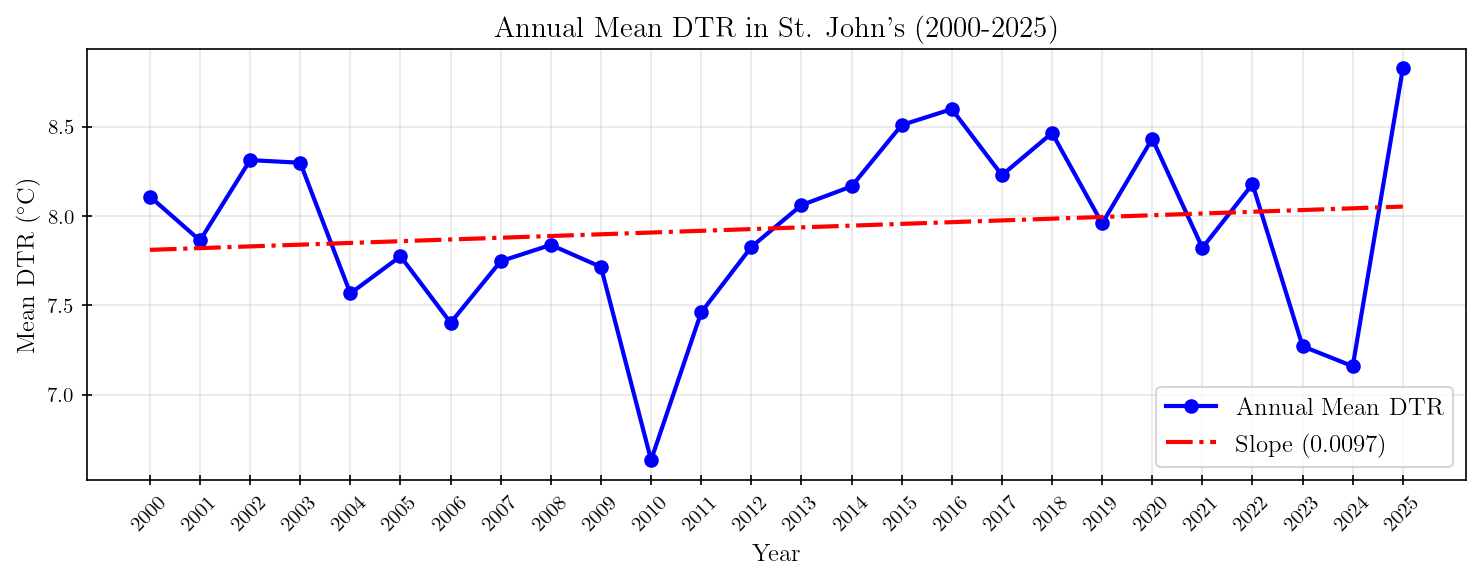

In [ ]:
# Generate trendline
trend_line = slope * annual_dtr.index + intercept

plt.figure(figsize=(10, 4))
plt.plot(annual_dtr.index, annual_dtr.values, "-b",
         marker='o', linewidth=2, markersize=6, label='Annual Mean DTR')
plt.plot(annual_dtr.index, trend_line, 'r-.', linewidth=2,
         label=f'Slope ({slope:.4f})')
plt.title('Annual Mean DTR in St. John\'s (2000-2025)')
plt.xlabel('Year')
plt.ylabel('Mean DTR ($^{\\circ}$C)')

plt.xticks(range(int(annual_dtr.index.min()), int(annual_dtr.index.max()) + 1, 1),
           rotation=45)

plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()

#### DTR Distribution by Month

<Figure size 1500x900 with 0 Axes>

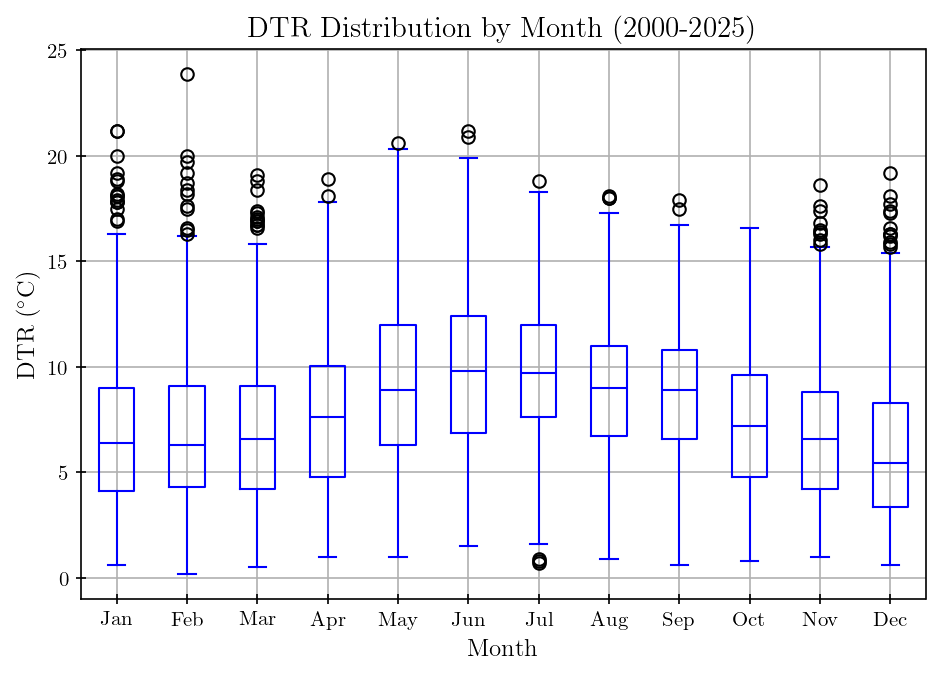

In [ ]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')

# Convert to categorical with chronological ordering
df['month_name'] = pd.Categorical(df['month_name'],
                                  categories=months,
                                  ordered=True)
plt.figure(figsize=(10, 6))
df.boxplot(column='DTR', color="blue", by='month_name')
plt.title('DTR Distribution by Month (2000-2025)')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('DTR ($^{\\circ}$C)')
plt.tight_layout()

#### Mean DTR by Month

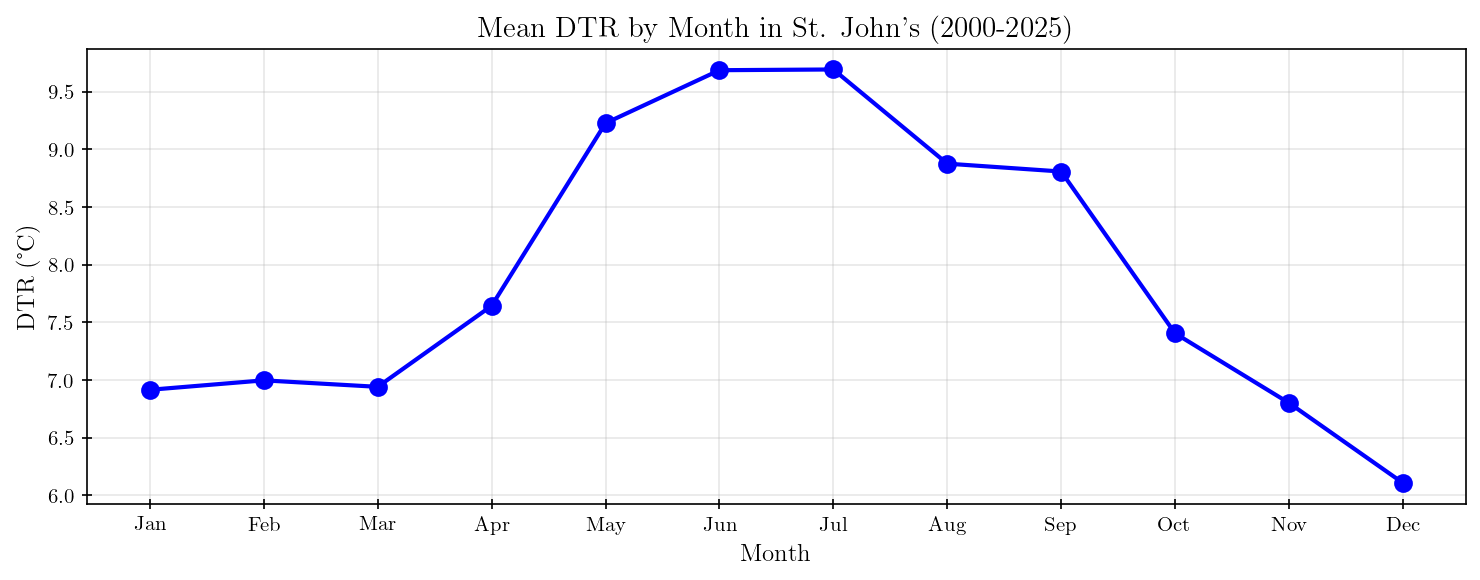

In [ ]:
# Calculate mean DTR for each month across all years
monthly_dtr = df.groupby(df['date'].dt.month)['DTR'].mean()

# Plot
plt.figure(figsize=(10, 4))
plt.plot(monthly_dtr.index, monthly_dtr.values,
         'o-b', linewidth=2, markersize=8, label='Mean')

plt.title('Mean DTR by Month in St. John\'s (2000-2025)')
plt.xlabel('Month')
plt.ylabel('DTR (°C)')

plt.xticks(range(1, 13), months)

plt.grid(True, alpha=0.3)
plt.tight_layout()

* Winter (Dec–Mar): Suppressed DTR (6.3–7.5 $^{\circ} \text{C}$) — ocean moderates day-night swings
* Spring (Apr–May): Transition (7.0–8.8 $^{\circ} \text{C}$) — increasing solar angle, clearer skies
* Summer (Jun–Aug): Peak DTR (9.5–9.6 $^{\circ} \text{C}$) — maximum contrast, strong daytime heating, clear nights
* Fall (Sep–Nov): Decline (6.4–8.1 $^{\circ} \text{C}$) — returning cloud cover, weakening solar angle

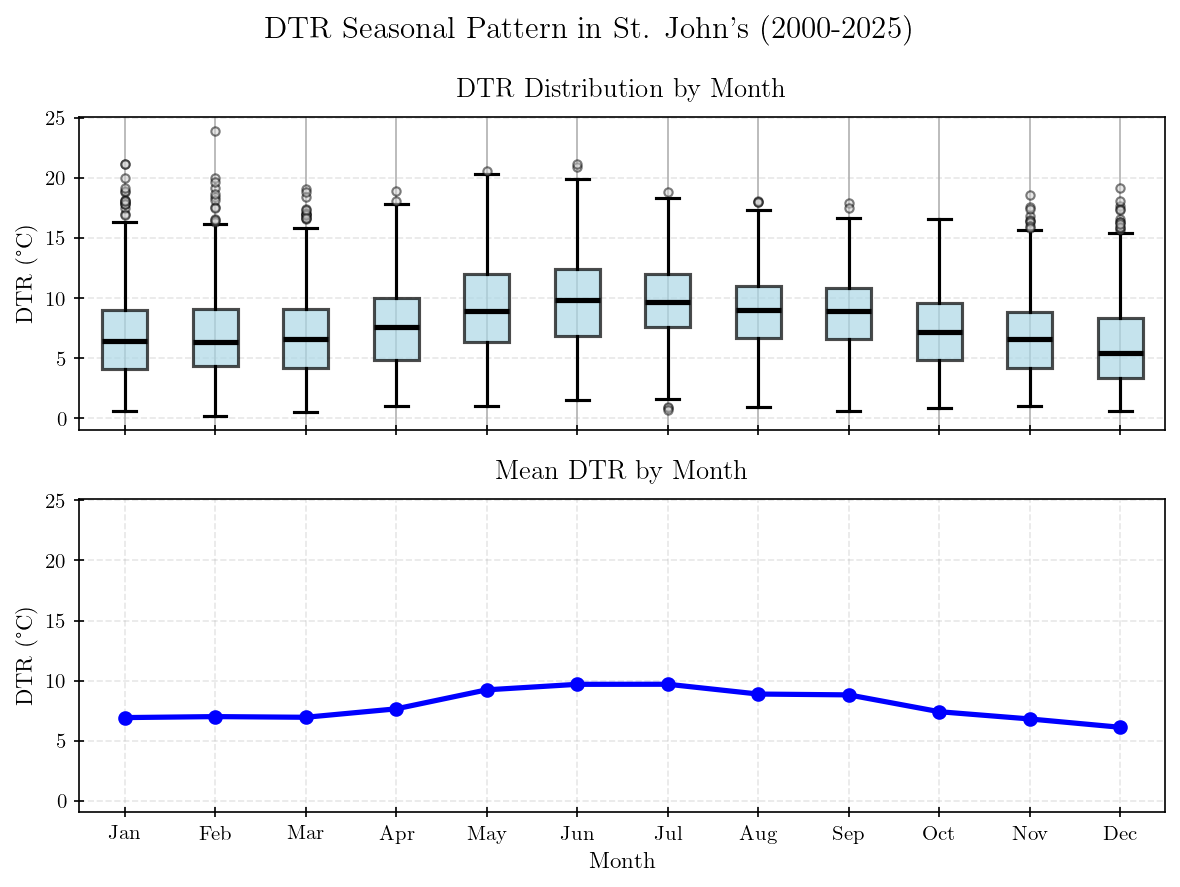

In [ ]:
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['month_name'] = pd.Categorical(df['month_name'],
                                  categories=months,
                                  ordered=True)

# Calculate monthly mean
monthly_dtr_mean = df.groupby(df['date'].dt.month)['DTR'].mean()

# Create figure with shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, sharey=True)

# Boxplot
df.boxplot(column='DTR', by='month_name', ax=ax1,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7, linewidth=1.5),
           medianprops=dict(color='black', linewidth=2.5),
           whiskerprops=dict(color='black', linewidth=1.5),
           capprops=dict(color='black', linewidth=1.5),
           flierprops=dict(marker='o', markerfacecolor='lightgray',
                           markersize=4, alpha=0.5))

ax1.set_title('DTR Distribution by Month',
              fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('')  # Remove x-label
ax1.set_ylabel('DTR (°C)', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')

# Mean line
ax2.plot(monthly_dtr.index, monthly_dtr.values,
         'o-', color='blue', linewidth=2.5, markersize=5,
         markeredgewidth=2)

ax2.set_title('Mean DTR by Month', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('DTR (°C)', fontsize=11)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(months)
ax2.grid(True, alpha=0.3, linestyle='--')

# Remove the default suptitle from boxplot
fig.suptitle('DTR Seasonal Pattern in St. John\'s (2000-2025)',
             fontsize=15, fontweight='bold')

# Adjust spacing
plt.tight_layout()

In [181]:
amplitude = monthly_dtr.max() - monthly_dtr.min()
print(f"Seasonal DTR amplitude: {amplitude:.1f}°C")

Seasonal DTR amplitude: 3.6°C


In [182]:
spring_dtr = monthly_dtr[3:6].mean()
fall_dtr = monthly_dtr[9:12].mean()
print(f"Spring mean: {spring_dtr:.1f}°C")
print(f"Fall mean: {fall_dtr:.1f}°C")

Spring mean: 8.9°C
Fall mean: 6.8°C


In [183]:
# Export csv with dtr values
df.to_csv("../data/dtr_dataset.csv", index=False)
print("DTR dataset exported!")

DTR dataset exported!


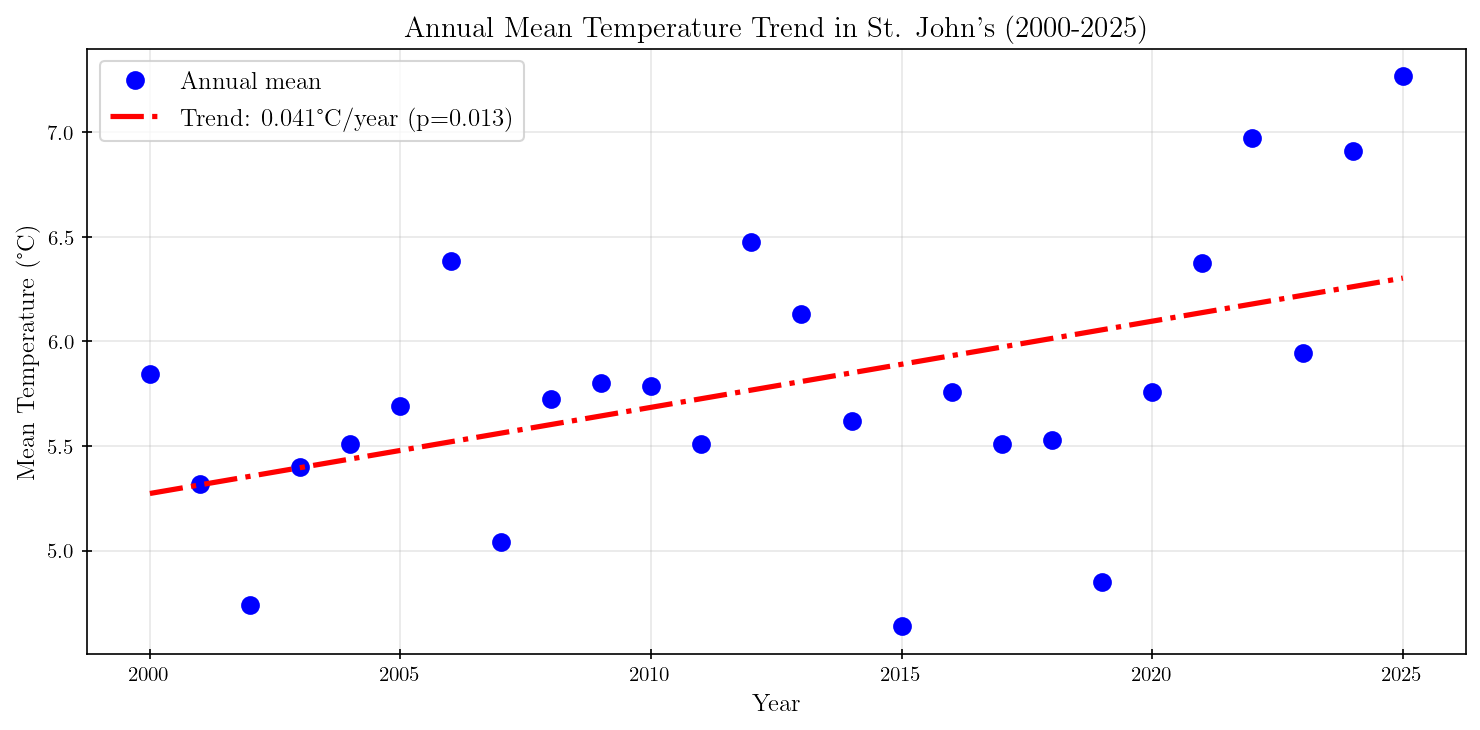

Temperature trend: 0.0412 ± 0.0153 °C/year
Total change (26 years): 1.07°C
p-value: 0.0130
R²: 0.231


In [ ]:
# Calculate annual mean temperature
# Assuming you want overall mean (average of T_min and T_max)
df['T_mean'] = (df['MIN_TEMPERATURE'] + df['MAX_TEMPERATURE']) / 2
annual_temp = df.groupby(df['date'].dt.year)['T_mean'].mean()

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(
    annual_temp.index, annual_temp.values
)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

# Scatter plot
ax.plot(annual_temp.index, annual_temp.values, 'o',
        markersize=8, color='blue', label='Annual mean')

# Trend line
x_trend = np.array([annual_temp.index.min(), annual_temp.index.max()])
y_trend = slope * x_trend + intercept
ax.plot(x_trend, y_trend, '-.', linewidth=2.5, color='red',
        label=f'Trend: {slope:.3f}°C/year (p={p_value:.3f})')

# Labels
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean Temperature (°C)', fontsize=12)
ax.set_title('Annual Mean Temperature Trend in St. John\'s (2000-2025)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"Temperature trend: {slope:.4f} ± {std_err:.4f} °C/year")
print(f"Total change (26 years): {slope * 26:.2f}°C")
print(f"p-value: {p_value:.4f}")
print(f"R²: {r_value**2:.3f}")